In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cd /content/drive/MyDrive/Projects

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit[visualization]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 61.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=00a11894804815345ae921de0f6444a88e767ebecf78fbea969cc622e4e92011
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


# 1. introduction

In [ ]:
from qiskit import *
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.compiler import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector, plot_state_qsphere
from math import pi
%matplotlib inline

In [ ]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
circuit.h(qr)
# circuit.h(0)
circuit.measure(qr, cr)
# circuit.draw(output='mpl')

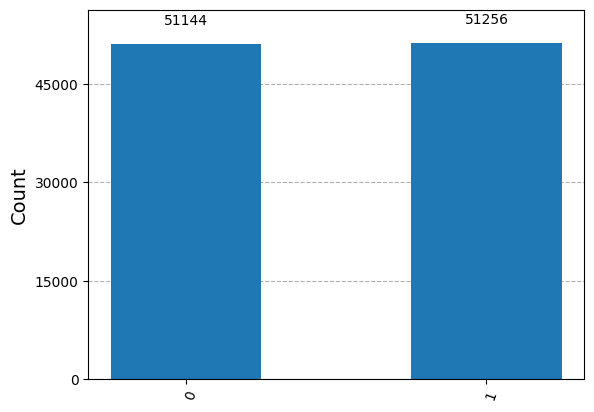

In [ ]:
qasm_simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit, shots=102400).result() # execute(circuit, simiulator, shots=1024).result()
# counts = result.get_counts()
# plot_histogram(counts)
plot_histogram(result.get_counts())

In [ ]:
print(result.get_counts())

{'0': 51144, '1': 51256}


## State vectors and Bloch spheres

In [ ]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
circuit.h(0)
circuit.measure(qr, cr)

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
state_vector = result.get_statevector()
# print(state_vector)
array_to_latex(state_vector) #, pretext="\\text{Statevector} = ")

<IPython.core.display.Latex object>

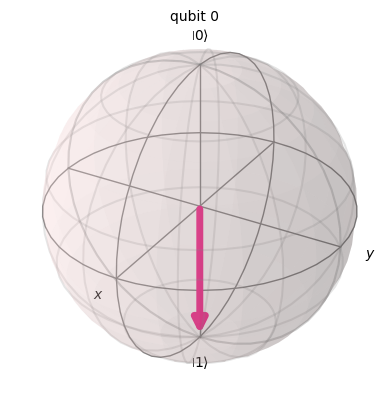

In [ ]:
plot_bloch_multivector(state_vector)

## Challenge 1

In [ ]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
circuit.measure(qr, cr)

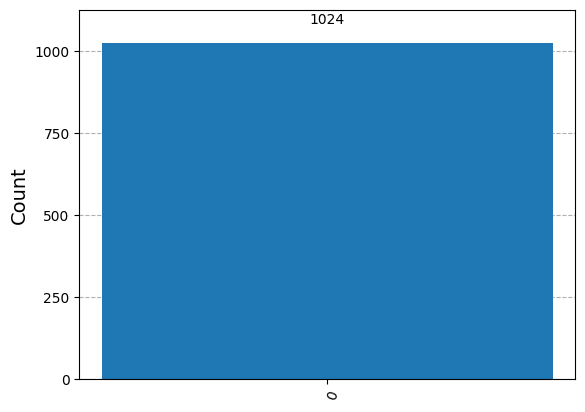

In [ ]:
qasm_simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts()
plot_histogram(counts)

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
state_vector = result.get_statevector()
array_to_latex(state_vector)

<IPython.core.display.Latex object>

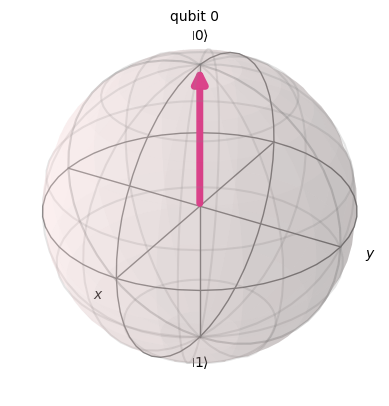

In [ ]:
plot_bloch_multivector(state_vector)

# 2. Multiple Quantum Bits

## Represent multiple qubits

In [ ]:
# qr = QuantumRegister(2)
# cr = ClassicalRegister(2)
# circuit = QuantumCircuit(qr, cr)
circuit = QuantumCircuit(2)
# circuit.h(qr)
circuit.h(0)
# circuit.measure(qr, cr)
circuit.measure_all()

In [ ]:
# simulator = Aer.get_backend('statevector_simulator')
qasm_simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit).result()
counts = result.get_counts()

# state_vector = result.get_statevector()
# array_to_latex(state_vector)

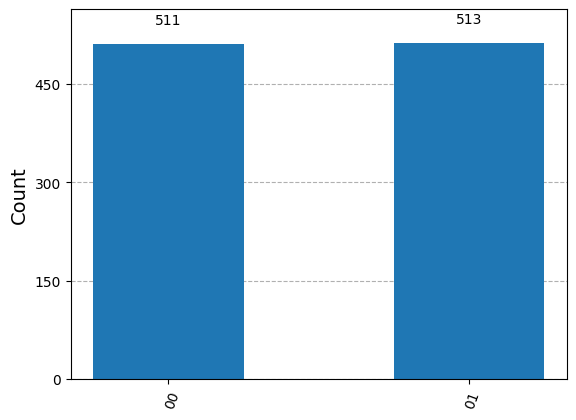

In [ ]:
# plot_bloch_multivector(state_vector)
plot_histogram(counts)

# 3. Single Qubit Pauli Gates

## Pauli-X gate

   ┌─────────┐┌───┐
q: ┤ Ry(π/4) ├┤ X ├
   └─────────┘└───┘


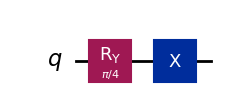

In [ ]:
circuit = QuantumCircuit(1)
# circuit.x(0)
# circuit.x(0)
circuit.ry(pi/4, 0)
circuit.x(0)
print(circuit)
circuit.draw(output='mpl')

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
state_vector = result.get_statevector()
array_to_latex(state_vector, prefix="\\text{statevector = }\n")

<IPython.core.display.Latex object>

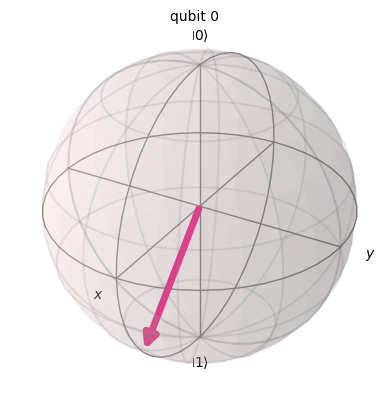

In [ ]:
plot_bloch_multivector(state_vector)

## Pauli-Y gate

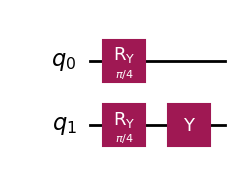

In [ ]:
circuit = QuantumCircuit(2)
# circuit.y(0)
# circuit.x(0)
circuit.ry(pi/4, [0, 1])
circuit.y(1)
circuit.draw(output='mpl')

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
state_vector = result.get_statevector()
array_to_latex(state_vector, prefix="\\text{statevector = }\n")

<IPython.core.display.Latex object>

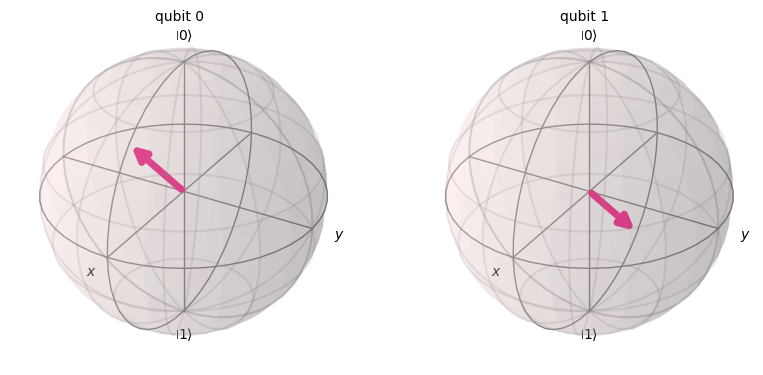

In [ ]:
plot_bloch_multivector(state_vector)

## Pauli-Z gate

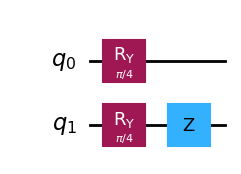

In [ ]:
circuit = QuantumCircuit(2)
circuit.ry(pi/4, [0, 1])
circuit.z(1)
circuit.draw(output='mpl')

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
state_vector = result.get_statevector()
array_to_latex(state_vector, prefix="\\text{statevector = }\n")

<IPython.core.display.Latex object>

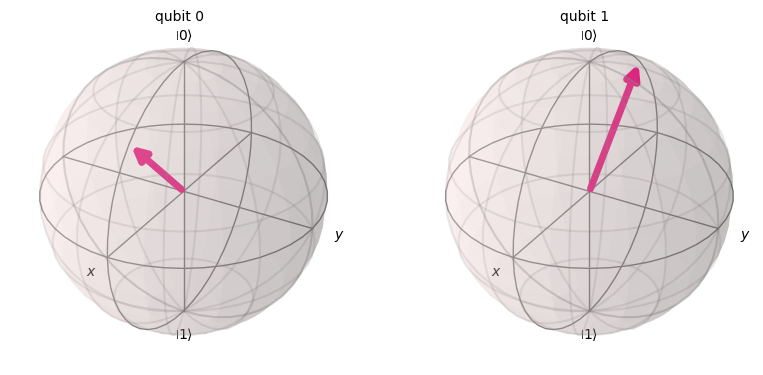

In [ ]:
plot_bloch_multivector(state_vector)

## Chanllenge 2

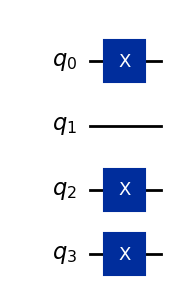

In [ ]:
circuit = QuantumCircuit(4)
circuit.x([0, 2, 3])
circuit.draw(output='mpl')

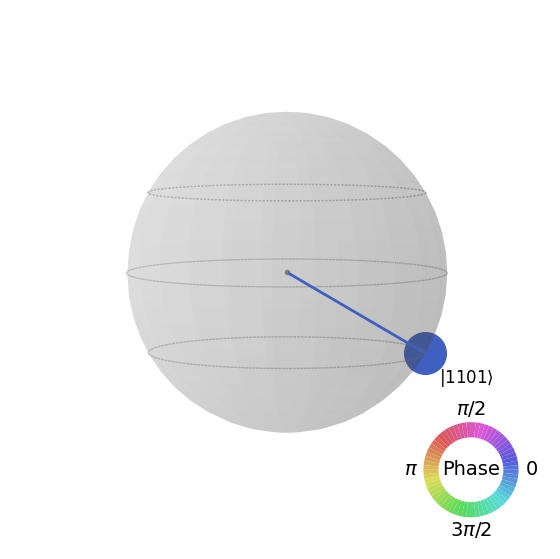

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(circuit, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

### Challenge: Binary numbers

#### Charli(lotte)

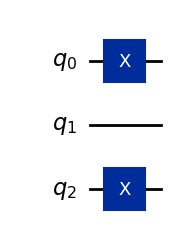

In [ ]:
charli = QuantumCircuit(3)
charli.x([0, 2])
charli.draw(output='mpl')

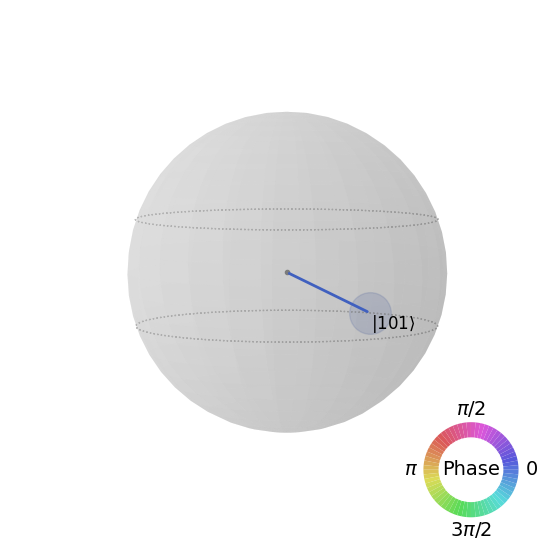

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(charli, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

#### Cheyenne

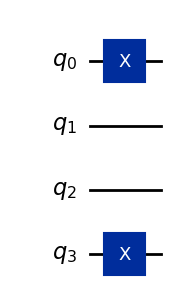

In [ ]:
cheyenne = QuantumCircuit(4)
cheyenne.x([0, 3]) # 9
cheyenne.draw(output='mpl')

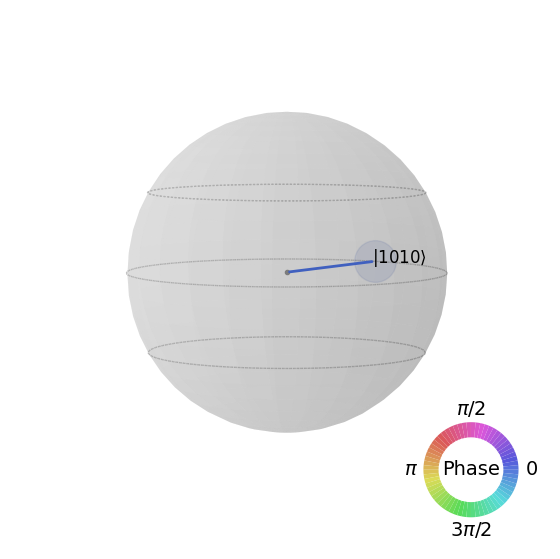

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(cheyenne, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

##### 2025

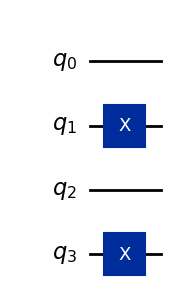

In [ ]:
cheyenne = QuantumCircuit(4)
cheyenne.x([1, 3]) # 10
cheyenne.draw(output='mpl')

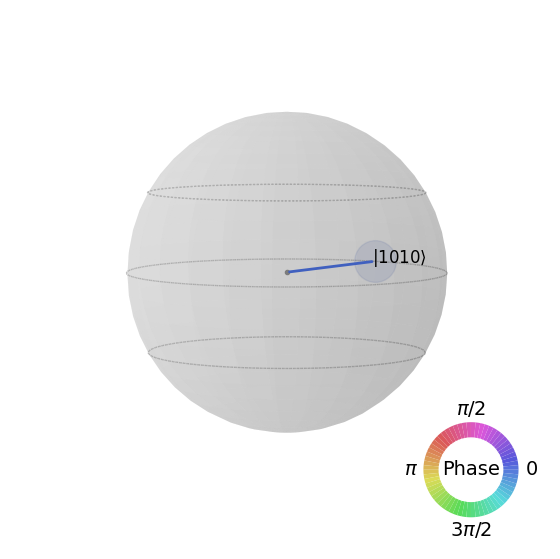

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(cheyenne, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

#### Kaydee

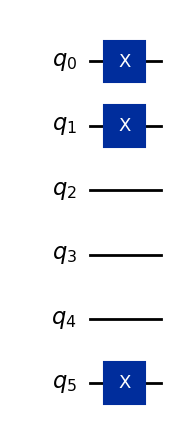

In [ ]:
Kaydee = QuantumCircuit(6)
Kaydee.x([0, 1, 5]) #
Kaydee.draw(output='mpl')

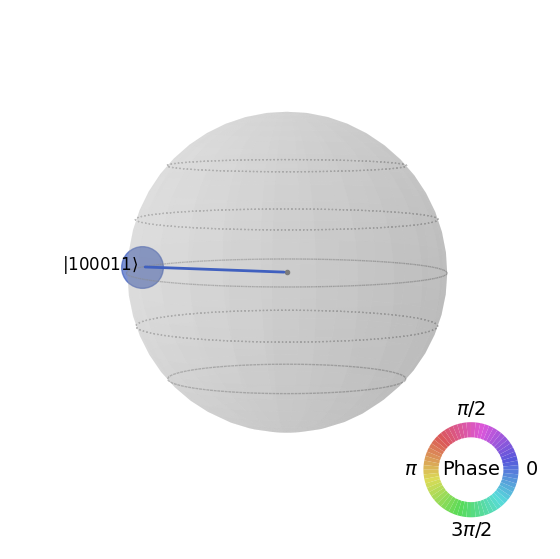

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(Kaydee, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

#### Eric

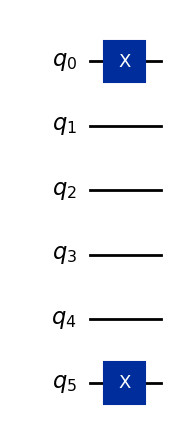

In [ ]:
Eric = QuantumCircuit(6)
Eric.x([0, 5])
Eric.draw(output='mpl')

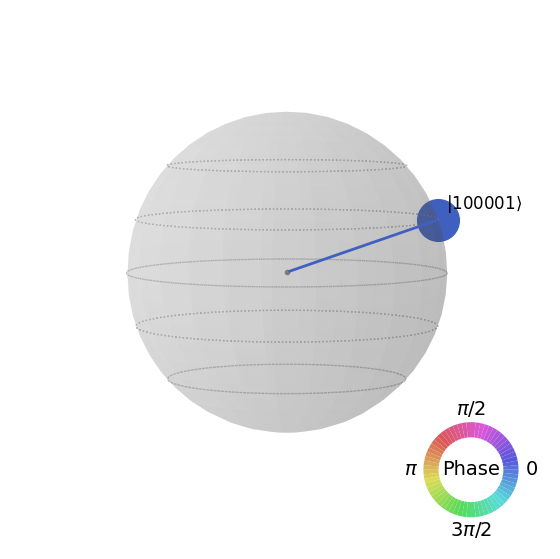

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(Eric, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

#### Andrew

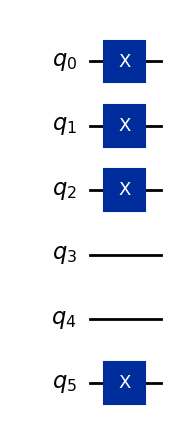

In [ ]:
Andy = QuantumCircuit(6)
Andy.x([0, 1, 2, 5])
Andy.draw(output='mpl')

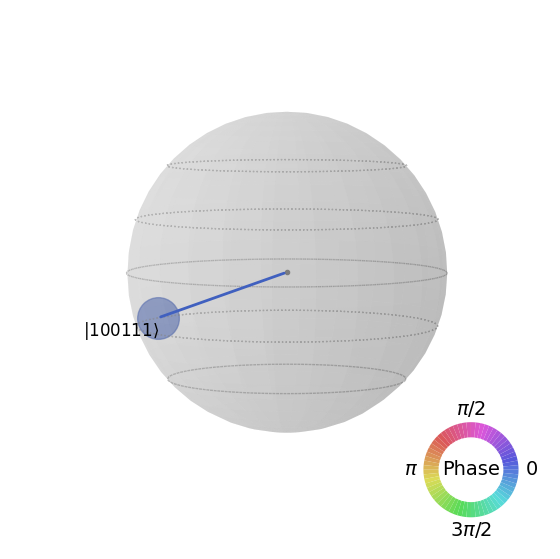

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(Andy, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

#### Mom

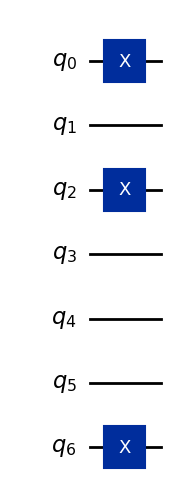

In [ ]:
mom = QuantumCircuit(7)
mom.x([0, 2, 6])
mom.draw(output='mpl')

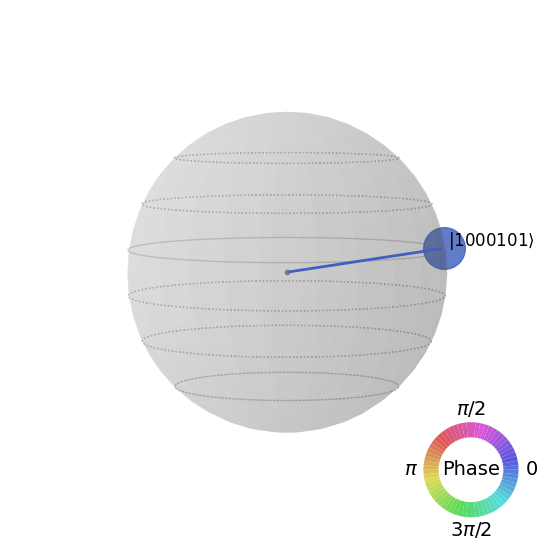

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(mom, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

#### Dad

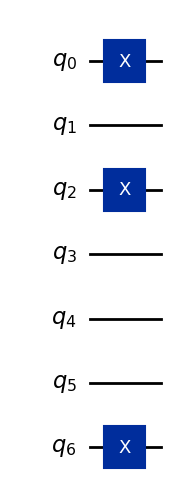

In [ ]:
dad = QuantumCircuit(7)
dad.x([0, 2, 6])
dad.draw(output='mpl')

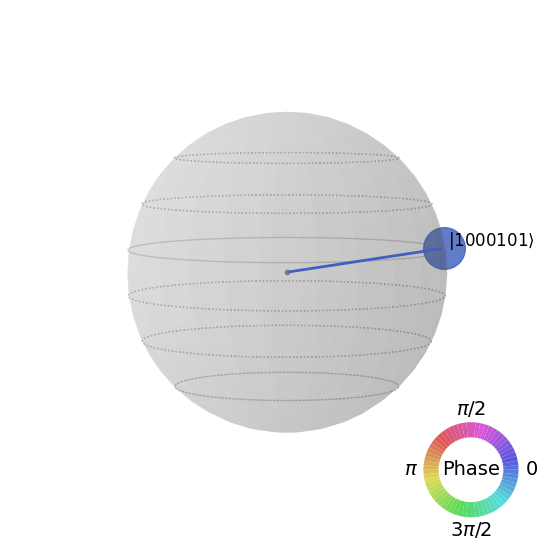

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
qc_comiled = transpile(dad, simulator)
result = simulator.run(qc_comiled).result()
statevector = result.get_statevector()
plot_state_qsphere(statevector)

# 4. Single-Qubit Superposition Gates

## Hadamard gate

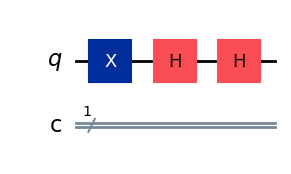

In [ ]:
circuit = QuantumCircuit(1, 1)
circuit.x(0)
circuit.h(0)
circuit.h(0)
circuit.draw(output='mpl')

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
state_vector = result.get_statevector()
array_to_latex(state_vector, prefix="\\text{statevector = }\n")

<IPython.core.display.Latex object>

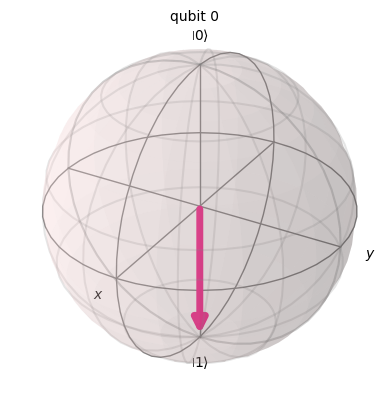

In [ ]:
plot_bloch_multivector(state_vector)

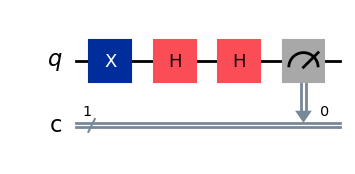

In [ ]:
circuit.measure(0, 0)
circuit.draw(output='mpl')

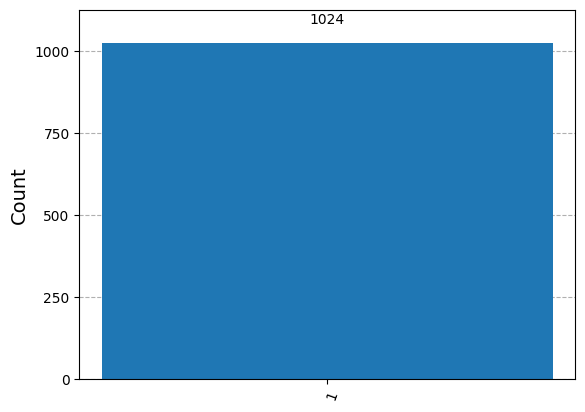

In [ ]:
qasm_simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit, shots=1024).result()
# counts = result.get_counts()
plot_histogram(result.get_counts())

## Phase shift gates

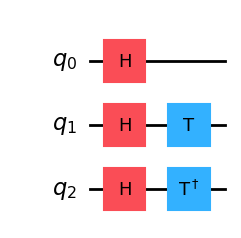

In [ ]:
circuit = QuantumCircuit(3)
circuit.h([0, 1, 2])
# circuit.s(1)
# circuit.sdg(2)
circuit.t(1)
circuit.tdg(2)
circuit.draw(output='mpl')

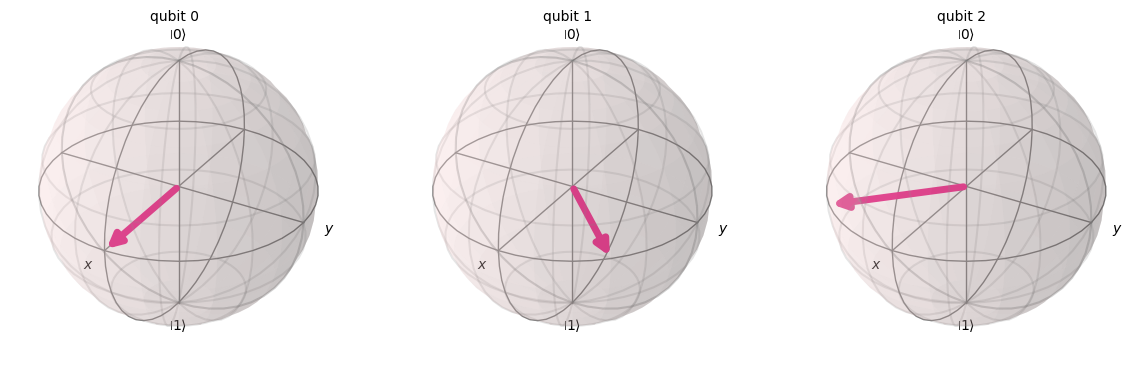

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
plot_bloch_multivector(result.get_statevector())

## Parameterized rotation gates

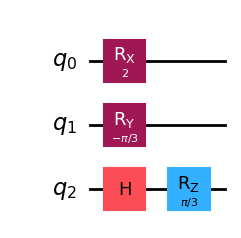

In [ ]:
circuit = QuantumCircuit(3)
# circuit.rx(pi/3, 0)
circuit.rx(2, 0)
circuit.ry(-pi/3, 1)
circuit.h(2)
circuit.rz(pi/3, 2)
circuit.draw(output='mpl')

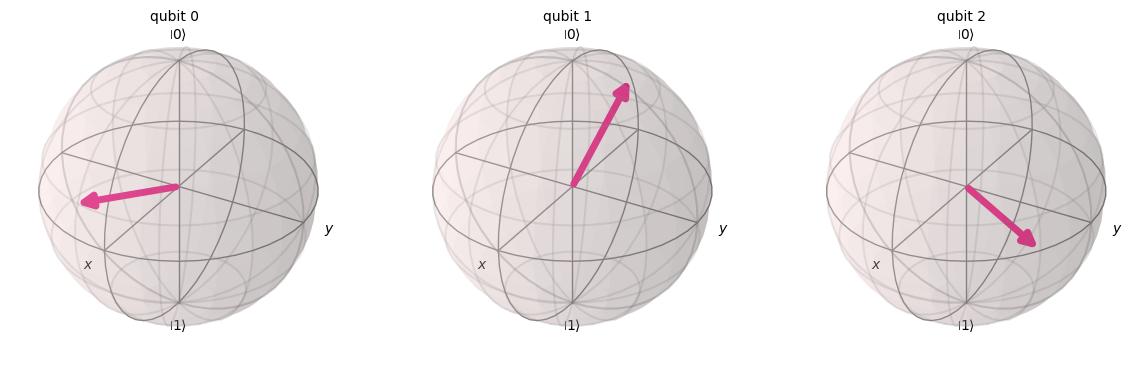

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
plot_bloch_multivector(result.get_statevector())

## Challenge (3): Random numbers

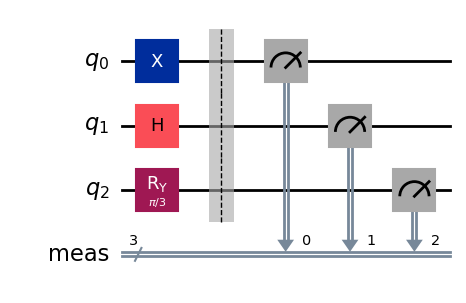

In [ ]:
circuit = QuantumCircuit(3)

circuit.x(0)
circuit.h(1)
circuit.ry(pi/3, 2)

circuit.measure_all()
circuit.draw(output='mpl')

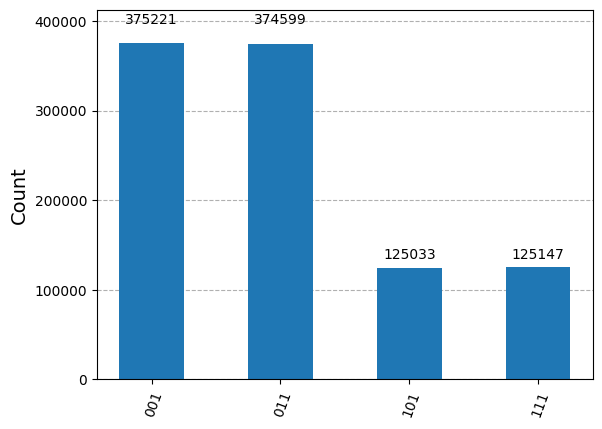

In [ ]:
qasm_simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit, shots=1000000).result()
counts = result.get_counts()
plot_histogram(counts)

# Multi-Qubit Gates

## Controlled-NOT (CNOT/cx) gate

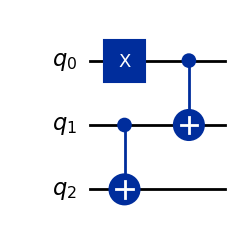

In [ ]:
circuit = QuantumCircuit(3)
circuit.x(0)
circuit.cx(1, 2) # CNOT gate
circuit.cx(0, 1) # CNOT gate
# circuit.cx(1, 2) # CNOT gate
circuit.draw(output='mpl')

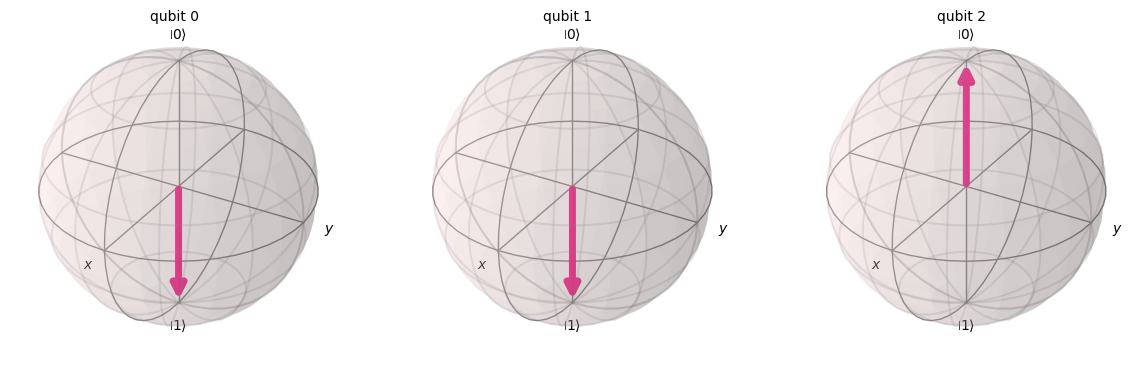

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
plot_bloch_multivector(result.get_statevector())

## Toffoli (ccx) gate

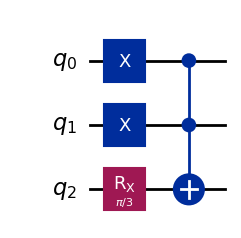

In [ ]:
circuit = QuantumCircuit(3)
circuit.x(0)
circuit.x(1)
circuit.rx(pi/3, 2)
circuit.ccx(0, 1, 2)
circuit.draw(output='mpl')

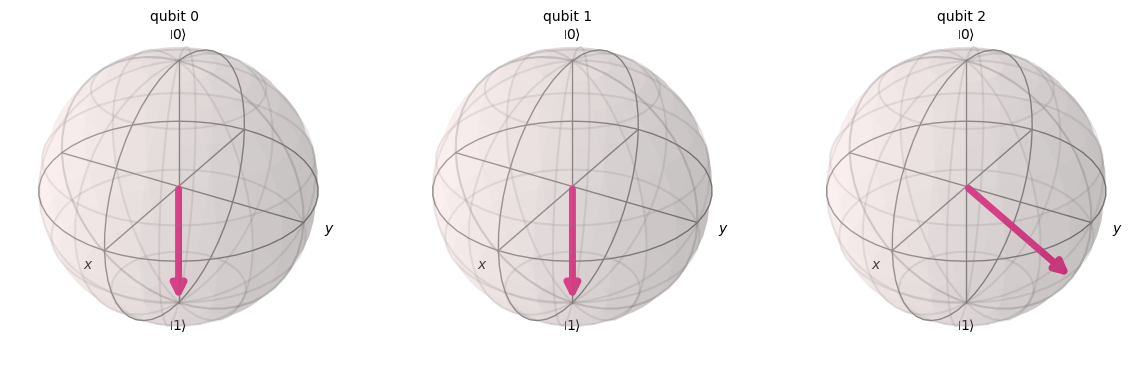

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
plot_bloch_multivector(result.get_statevector())

## Swap/Fredkin (cswap) gates

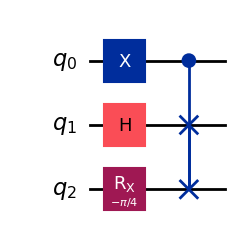

In [ ]:
circuit = QuantumCircuit(3)
circuit.x(0)
circuit.h(1)
circuit.rx(-pi/4, 2)
# circuit.swap(1, 2)
circuit.cswap(0, 1, 2) # Fredkin gate
circuit.draw(output='mpl')

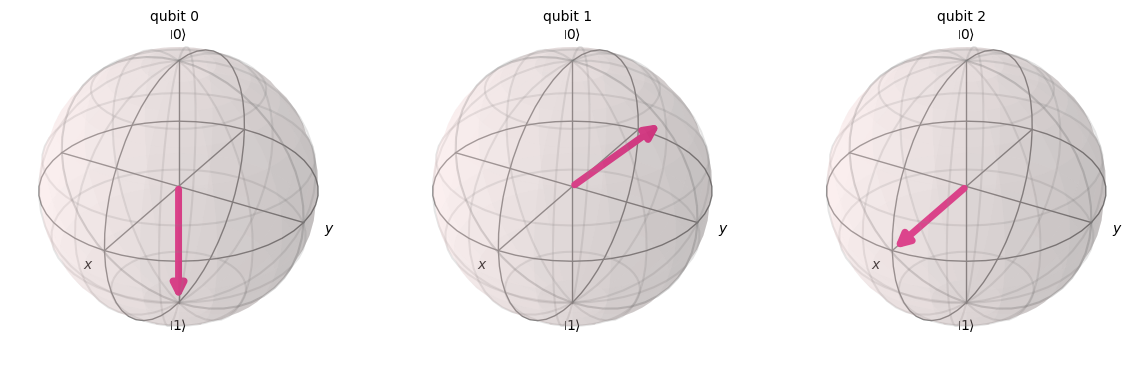

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
plot_bloch_multivector(result.get_statevector())

## Challenge (4): Classical two-bit adder

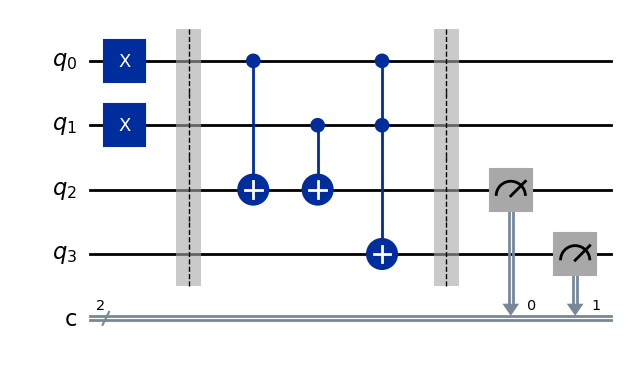

In [ ]:
circuit =  QuantumCircuit(4, 2)
circuit.x(0) # initialize input A
circuit.x(1) # initialize input B
circuit.barrier()

circuit.cx(0, 2) # CNOT gate
circuit.cx(1, 2) # CNOT gate
circuit.ccx(0, 1, 3) # Toffoli gate

circuit.barrier()
circuit.measure(2, 0) # measure SUM
circuit.measure(3, 1) # measure CARRY-OUT
circuit.draw(output='mpl')

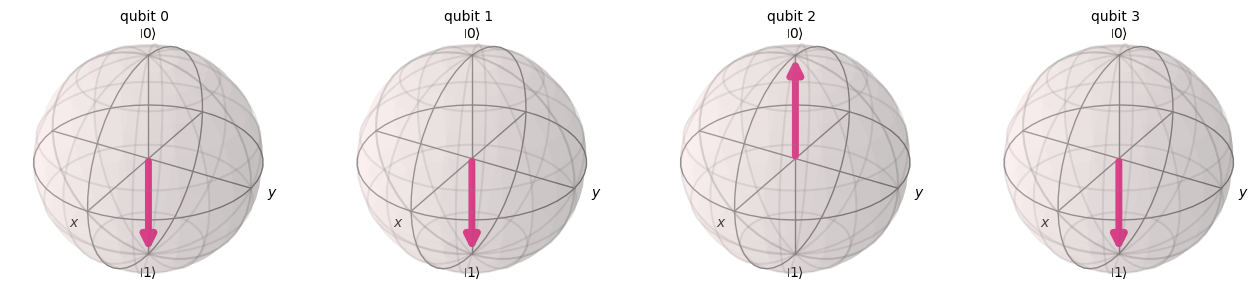

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
plot_bloch_multivector(result.get_statevector())

# 6. Quantum Entanglement

## Simulate a bell state

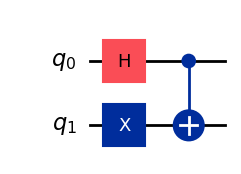

In [ ]:
circuit = QuantumCircuit(2)
circuit.x(1)
circuit.h(0)
circuit.cx(0, 1) # CNOT
# circuit.h(0)
circuit.draw(output='mpl')

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
state_vector = result.get_statevector()
array_to_latex(state_vector, prefix="\\text{statevector = }\n")

<IPython.core.display.Latex object>

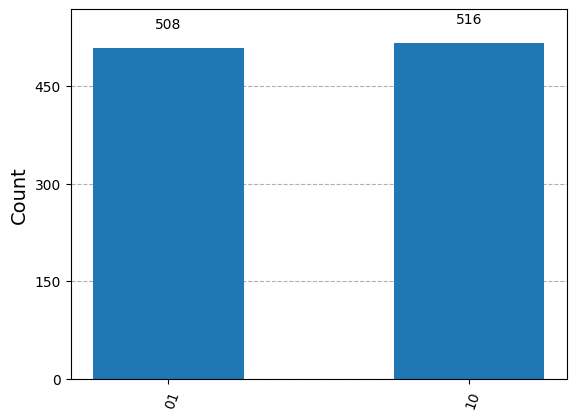

In [ ]:
circuit.measure_all()
qasm_simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit).result()
plot_histogram(result.get_counts())

## Challenge  (5): Entangle three qubits

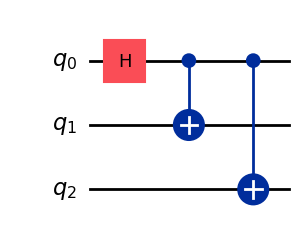

In [ ]:
circuit = QuantumCircuit(3)

circuit.h(0)
circuit.cx(0, 1) # CNOT
# circuit.cx(1, 2) # CNOT
circuit.cx(0, 2) # CNOT

circuit.draw(output='mpl')

In [ ]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
state_vector = result.get_statevector()
array_to_latex(state_vector, prefix="\\text{statevector = }\n")

<IPython.core.display.Latex object>

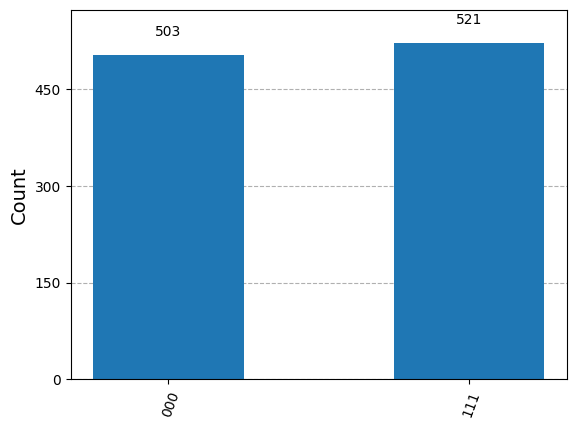

In [ ]:
circuit.measure_all()
qasm_simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit).result()
plot_histogram(result.get_counts())

# 7. Real Quantum Hardware

## Use Qiskit with real quantum hardware

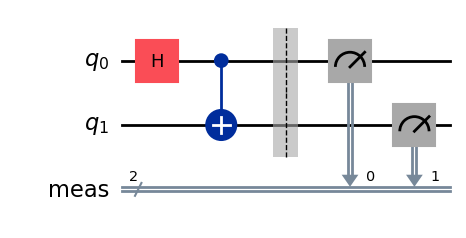

In [ ]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()
circuit.draw(output='mpl')

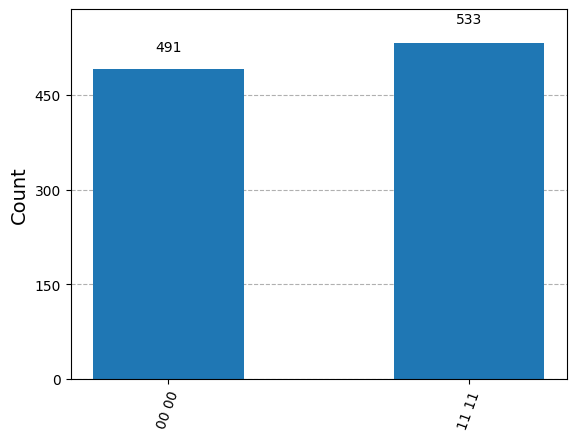

In [ ]:
qasm_simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(circuit, backend=qasm_simulator)
result = qasm_simulator.run(compiled_circuit).result()
plot_histogram(result.get_counts())

In [2]:
!pip install qiskit-ibm-provider
!pip install qiskit-ibm-runtime
# !pip install qiskit-terra # Qiskit <1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.9/249.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 2.5 MB/s eta 0:00:00


In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService
# from qiskit_ibm_provider.monitor import job_monitor # Not compatible with Qiskit 1.0+